# Modelagem de Sobrevida - LUAD

## Imports

In [ ]:
!python -m pip install numpy pandas matplotlib scikit-learn lifelines scikit-survival openpyxl jupyter ipykernel

^C


In [ ]:
from pathlib import Path
from itertools import product
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import t

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

from lifelines import CoxPHFitter, WeibullAFTFitter
from lifelines.utils import concordance_index

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

import torch
import torchtuples as tt
from pycox.models import CoxPH, DeepHitSingle
from pycox.evaluation import EvalSurv

## Settings

In [ ]:
cohort = "LUAD"

project_dir = Path("..").resolve()

data_path = project_dir / "data" / "processed" / "luad" / "luad_integrated_full.csv"

results_dir = project_dir / "reports" / "results" / "luad"
figures_dir = project_dir / "reports" / "figures" / "luad"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

time_col = "surv__OS.time"
event_col = "surv__OS"

seed = 42
n_splits = 5

In [ ]:
print(data_path)

df = pd.read_csv(data_path, sep=";")

print("Shape:", df.shape)
df.head()

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\data\processed\luad\luad_integrated_full.csv
Shape: (502, 20601)


,patient_id,surv__OS.time,surv__OS,clin__age_at_index.demographic,clin__age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,clin__pack_years_smoked.exposures,clin__cigarettes_per_day.exposures,clin__age_at_index.demographic_missing,clin__age_at_earliest_diagnosis_in_years.diagnoses.xena_derived_missing,clin__pack_years_smoked.exposures_missing,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
0,TCGA-05-4249,1523.0,0,67.0,67.210959,52.0,2.849315,0,0,0,...,0.7171,1.1940,6.1071,3.6169,9.0818,10.8954,7.1886,9.9124,7.3765,9.6492
1,TCGA-05-4250,121.0,1,79.0,79.638356,47.0,2.575342,0,0,0,...,0.0000,0.4132,6.4410,0.0000,8.8525,12.8524,8.1790,11.2441,4.9927,10.1166
2,TCGA-05-4382,607.0,0,68.0,68.131507,62.0,3.397260,0,0,0,...,1.7626,0.0000,4.8339,3.8719,10.0340,12.7050,7.8320,10.6372,4.4633,10.2290
3,TCGA-05-4384,426.0,0,66.0,66.879452,20.0,1.095890,0,0,0,...,0.6879,1.1517,5.5861,0.0000,9.0989,12.0031,8.9340,11.3264,6.9302,9.8297
4,TCGA-05-4389,1369.0,0,70.0,70.301370,43.0,2.356164,0,0,0,...,3.1785,0.0000,5.8082,1.8815,8.7193,10.2429,6.9245,10.7438,7.6145,10.7381


In [ ]:
if "patient_id" in df.columns:
    patient_ids = df["patient_id"].copy()
    df = df.drop(columns=["patient_id"])
else:
    patient_ids = pd.Series(range(len(df)), name="patient_id")

In [ ]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Total de nulos:", int(df.isna().sum().sum()))

nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0].head(30)

Total de nulos: 0


Series([], dtype: int64)

In [ ]:
df[event_col] = df[event_col].astype(int)
df[time_col] = df[time_col].astype(float)

print(df[event_col].value_counts())

print( round(df[event_col].mean() * 100, 2), "%")

print("Mínimo:", df[time_col].min())
print("Mediana:", df[time_col].median())
print("Máximo:", df[time_col].max())

surv__OS
0    320
1    182
Name: count, dtype: int64
36.25 %
Mínimo: 4.0
Mediana: 656.5
Máximo: 7248.0


In [ ]:
# Genes clássicos de LUAD
genes_luad_classicos = [
    "TP53", "KRAS", "EGFR", "BRAF", "PIK3CA", "MET", "RIT1",
    "STK11", "KEAP1", "NF1", "RB1", "CDKN2A", "SETD2",
    "ARID1A", "SMARCA4", "RBM10", "U2AF1"
]

# Assinatura imune
genes_luad_imune_9 = [
    "BTK", "CCR6", "S100A10", "SEMA3C", "GPI",
    "SCG2", "TNFRSF11A", "CCL20", "DKK1"
]

# Assinatura imune/metástase linfonodal
genes_luad_imune_8 = [
    "IKBKB", "LTBR", "MIF", "PPARD", "PPIA",
    "PSME3", "S100A6", "SEMA4B"
]

# Assinatura prognóstica/quimioterapia
genes_luad_quimio = [
    "BTK", "FGFR2", "PIM2", "CHEK1", "CDK1"
]

# Assinatura glicolítica
genes_luad_glicolise = [
    "AGRN", "AKR1A1", "DDIT4", "HMMR"
]

genes_literatura = (
    genes_luad_classicos
    + genes_luad_imune_9
    + genes_luad_imune_8
    + genes_luad_quimio
    + genes_luad_glicolise
)

genes_literatura = [str(g).replace("\u200b", "").strip() for g in genes_literatura]
genes_literatura = list(dict.fromkeys(genes_literatura))

genes_candidatos = [g for g in genes_literatura if g in df.columns]
genes_ausentes = [g for g in genes_literatura if g not in df.columns]


In [ ]:
clin_cols = [
    c for c in df.columns
    if c.startswith("clin__")
    and c not in [time_col, event_col]
    and "vital_status" not in c.lower()
]

feature_cols = clin_cols + genes_candidatos
feature_cols = list(dict.fromkeys(feature_cols))

X = df[feature_cols].copy()
tempo = df[time_col].copy()
evento = df[event_col].copy()

mask_valid_survival = (
    tempo.notna()
    & evento.notna()
    & np.isfinite(tempo)
    & (tempo > 0)
)

X = X.loc[mask_valid_survival].copy()
tempo = tempo.loc[mask_valid_survival].astype(float).copy()
evento = evento.loc[mask_valid_survival].astype(int).copy()

print("Pacientes após filtro de sobrevida:", X.shape[0])
print("Colunas clínicas:", len(clin_cols))
print("Genes candidatos presentes:", len(genes_candidatos))
print(genes_candidatos)
print("Genes candidatos ausentes:", len(genes_ausentes))
print(genes_ausentes)
print("Total de features antes da seleção por fold:", X.shape[1])


Pacientes após filtro de sobrevida: 502
Colunas clínicas: 68
Genes candidatos presentes: 42
['TP53', 'KRAS', 'EGFR', 'BRAF', 'PIK3CA', 'MET', 'RIT1', 'STK11', 'KEAP1', 'NF1', 'RB1', 'CDKN2A', 'SETD2', 'ARID1A', 'SMARCA4', 'RBM10', 'U2AF1', 'BTK', 'CCR6', 'S100A10', 'SEMA3C', 'GPI', 'SCG2', 'TNFRSF11A', 'CCL20', 'DKK1', 'IKBKB', 'LTBR', 'MIF', 'PPARD', 'PPIA', 'PSME3', 'S100A6', 'SEMA4B', 'FGFR2', 'PIM2', 'CHEK1', 'CDK1', 'AGRN', 'AKR1A1', 'DDIT4', 'HMMR']
Genes candidatos ausentes: 0
[]
Total de features antes da seleção por fold: 110


In [ ]:
skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=seed
)

folds = list(skf.split(X, evento))

print("Quantidade de folds:", len(folds))

for i, (train_idx, test_idx) in enumerate(folds, start=1):
    print(
        f"Fold {i}:",
        "treino =", len(train_idx),
        ", teste =", len(test_idx),
        ", eventos teste =", int(evento.iloc[test_idx].sum())
    )

Quantidade de folds: 5
Fold 1: treino = 401 , teste = 101 , eventos teste = 37
Fold 2: treino = 401 , teste = 101 , eventos teste = 37
Fold 3: treino = 402 , teste = 100 , eventos teste = 36
Fold 4: treino = 402 , teste = 100 , eventos teste = 36
Fold 5: treino = 402 , teste = 100 , eventos teste = 36


## Pré-processamento dentro dos folds

In [ ]:
def variancia(X_train, X_test, threshold=0.01):
    seletor = VarianceThreshold(threshold=threshold)

    X_train_sel = seletor.fit_transform(X_train)
    X_test_sel = seletor.transform(X_test)

    colunas_ok = X_train.columns[seletor.get_support()]
    colunas_removidas = X_train.columns[~seletor.get_support()].tolist()

    X_train_sel = pd.DataFrame(X_train_sel, columns=colunas_ok, index=X_train.index)
    X_test_sel = pd.DataFrame(X_test_sel, columns=colunas_ok, index=X_test.index)

    return X_train_sel, X_test_sel, colunas_removidas

In [ ]:
def colinearidade(X_train, X_test, limite=0.90):
    corr = X_train.corr().abs()
    matriz_superior = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    colunas_remover = [
        col for col in matriz_superior.columns
        if any(matriz_superior[col] > limite)
    ]

    X_train_ok = X_train.drop(columns=colunas_remover, errors="ignore")
    X_test_ok = X_test.drop(columns=colunas_remover, errors="ignore")

    return X_train_ok, X_test_ok, colunas_remover

In [ ]:
def padronizar(X_train, X_test):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

    return X_train_scaled, X_test_scaled

In [ ]:
def validar(X_train, X_test):
    if X_train.shape[1] == 0:
        raise ValueError("Nenhuma variável ficou disponível depois do pré-processamento.")

    if X_train.isna().sum().sum() > 0 or X_test.isna().sum().sum() > 0:
        raise ValueError("Ainda existem nulos depois do pré-processamento.")

    if not np.isfinite(X_train.to_numpy()).all() or not np.isfinite(X_test.to_numpy()).all():
        raise ValueError("Ainda existem valores infinitos depois do pré-processamento.")

In [ ]:
def fold_(X_train, X_test, usar_scaler=True, var_threshold=0.01, corr_threshold=0.90):
    X_train_prep, X_test_prep, removidas_var = variancia(
        X_train,
        X_test,
        threshold=var_threshold
    )

    X_train_prep, X_test_prep, removidas_corr = colinearidade(
        X_train_prep,
        X_test_prep,
        limite=corr_threshold
    )

    if usar_scaler:
        X_train_prep, X_test_prep = padronizar(X_train_prep, X_test_prep)

    validar(X_train_prep, X_test_prep)

    info = {
        "baixa_variancia": removidas_var,
        "clin_baixa_variancia": [c for c in removidas_var if c.startswith("clin__")],
        "genes_baixa_variancia": [c for c in removidas_var if not c.startswith("clin__")],
        "colinearidade": removidas_corr,
        "clin_colinearidade": [c for c in removidas_corr if c.startswith("clin__")],
        "genes_colinearidade": [c for c in removidas_corr if not c.startswith("clin__")],
    }

    return X_train_prep, X_test_prep, info

In [ ]:
def y_sksurv(tempo_parte, evento_parte):
    return Surv.from_arrays(
        event=evento_parte.astype(bool).values,
        time=tempo_parte.astype(float).values
    )

In [ ]:
def selecionar_genes(X_train, tempo_train, evento_train, genes_candidatos, p_limite=0.05):
    linhas = []

    for gene in genes_candidatos:
        if gene not in X_train.columns:
            continue

        tmp = pd.DataFrame({
            "tempo": tempo_train.values,
            "evento": evento_train.values,
            gene: X_train[gene].values
        }).dropna()

        if tmp.shape[0] < 20 or tmp[gene].nunique() < 2:
            continue

        desvio = tmp[gene].std()
        if desvio == 0 or pd.isna(desvio):
            continue

        tmp[gene] = (tmp[gene] - tmp[gene].mean()) / desvio

        try:
            cph_uni = CoxPHFitter()
            cph_uni.fit(tmp, duration_col="tempo", event_col="evento")
            s = cph_uni.summary.loc[gene]

            linhas.append({
                "gene": gene,
                "coef": s["coef"],
                "HR": s["exp(coef)"],
                "p": s["p"]
            })
        except Exception:
            continue

    tabela = pd.DataFrame(linhas)

    if tabela.empty:
        return [], tabela

    tabela = tabela.sort_values("p").reset_index(drop=True)
    genes_fold = tabela.loc[tabela["p"] < p_limite, "gene"].tolist()

    return genes_fold, tabela

In [ ]:
def x_fold(X_train, X_test, tempo_train, evento_train, verbose=True):
    genes_fold, tabela_genes = selecionar_genes(
        X_train=X_train,
        tempo_train=tempo_train,
        evento_train=evento_train,
        genes_candidatos=genes_candidatos,
        p_limite=0.05
    )

    cols_clinicas = [c for c in clin_cols if c in X_train.columns]
    cols_fold = list(dict.fromkeys(cols_clinicas + genes_fold))

    if verbose:
        print("Genes selecionados neste fold:", len(genes_fold), genes_fold)

    return X_train[cols_fold].copy(), X_test[cols_fold].copy(), genes_fold, tabela_genes

In [ ]:
resultados_folds = []
resumos = {}
tuning_nested = []

In [ ]:
def limpeza(nome_modelo):
    global resultados_folds, tuning_nested

    resultados_folds = [
        linha for linha in resultados_folds
        if linha["modelo"] != nome_modelo
    ]

    tuning_nested = [
        linha for linha in tuning_nested
        if linha["modelo"] != nome_modelo
    ]

    if nome_modelo in resumos:
        del resumos[nome_modelo]

In [ ]:
def _resultado(modelo, fold, c_train, c_test, genes_fold=None, hiperparametros="", info=None):
    genes_fold = genes_fold or []
    info = info or {}

    resultados_folds.append({
        "coorte": cohort,
        "modelo": modelo,
        "fold": fold,
        "c_index_train": c_train,
        "c_index_test": c_test,
        "gap": c_train - c_test,
        "n_genes_fold": len(genes_fold),
        "genes_fold": ", ".join(genes_fold),
        "hiperparametros_fold": hiperparametros,
        "n_baixa_variancia": len(info.get("baixa_variancia", [])),
        "n_clin_baixa_variancia": len(info.get("clin_baixa_variancia", [])),
        "n_colinearidade": len(info.get("colinearidade", [])),
        "n_clin_colinearidade": len(info.get("clin_colinearidade", [])),
    })

In [ ]:
def resultado(nome_modelo):
    temp = pd.DataFrame(resultados_folds)
    temp = temp[temp["modelo"] == nome_modelo]

    resumo = {
        "coorte": cohort,
        "modelo": nome_modelo,
        "c_index_treino_medio": temp["c_index_train"].mean(),
        "c_index_teste_medio": temp["c_index_test"].mean(),
        "dp_teste": temp["c_index_test"].std(),
        "gap_medio": temp["gap"].mean()
    }

    resumos[nome_modelo] = resumo
    return pd.DataFrame([resumo])


## Tuning aninhado dos hiperparâmetros

In [ ]:
param_grid_cox = {
    "penalizer": [0.1, 1.0, 10.0]
}

param_grid_weibull = {
    "penalizer": [0.1, 1.0, 10.0]
}

param_grid_rsf = {
    "n_estimators": [100, 200],
    "min_samples_split": [15, 25],
    "min_samples_leaf": [10, 20],
    "max_features": ["sqrt", 5]
}

param_grid_gbsa = {
    "n_estimators": [100, 150],
    "learning_rate": [0.01, 0.02],
    "max_depth": [1, 2],
    "subsample": [0.7]
}

## Funções

In [ ]:
def grid_params(param_grid):
    chaves = list(param_grid.keys())
    valores = [param_grid[chave] for chave in chaves]
    return [dict(zip(chaves, item)) for item in product(*valores)]


def params_txt(params):
    return "; ".join([f"{chave}={valor}" for chave, valor in params.items()])


def ajustar_params(params, n_features):
    params = params.copy()

    if "max_features" in params:
        valor = params["max_features"]
        if isinstance(valor, int) and valor > n_features:
            params["max_features"] = n_features

    return params


def pred_tempo(pred):
    pred = pd.Series(np.asarray(pred).ravel()).replace([np.inf, -np.inf], np.nan)

    if pred.notna().sum() == 0:
        pred = pd.Series(np.ones(len(pred)), index=pred.index)
    else:
        pred = pred.fillna(pred.max())

    return pred

In [ ]:
def score_clas(nome_modelo, params, X_train, X_out, tempo_train, tempo_out, evento_train, evento_out, random_state=None):
    params = ajustar_params(params, n_features=X_train.shape[1])
    random_state = seed if random_state is None else random_state

    if nome_modelo == "CoxPH":
        df_train = X_train.copy()
        df_train[time_col] = tempo_train.values
        df_train[event_col] = evento_train.values

        modelo = CoxPHFitter(**params)
        modelo.fit(df_train, duration_col=time_col, event_col=event_col)

        risco_out = modelo.predict_partial_hazard(X_out)
        c_out = concordance_index(tempo_out, -risco_out, evento_out)

    elif nome_modelo == "Weibull AFT":
        df_train = X_train.copy()
        df_train[time_col] = tempo_train.values
        df_train[event_col] = evento_train.values

        modelo = WeibullAFTFitter(**params)
        modelo.fit(df_train, duration_col=time_col, event_col=event_col)

        pred_out = pred_tempo(modelo.predict_median(X_out))
        c_out = concordance_index(tempo_out, pred_out, evento_out)

    elif nome_modelo == "RSF":
        y_train = y_sksurv(tempo_train, evento_train)

        modelo = RandomSurvivalForest(
            **params,
            n_jobs=-1,
            random_state=random_state
        )
        modelo.fit(X_train, y_train)

        risco_out = modelo.predict(X_out)
        c_out = concordance_index_censored(
            evento_out.astype(bool),
            tempo_out,
            risco_out
        )[0]

    elif nome_modelo == "GBSA":
        y_train = y_sksurv(tempo_train, evento_train)

        modelo = GradientBoostingSurvivalAnalysis(
            **params,
            random_state=random_state
        )
        modelo.fit(X_train, y_train)

        risco_out = modelo.predict(X_out)
        c_out = concordance_index_censored(
            evento_out.astype(bool),
            tempo_out,
            risco_out
        )[0]

    return c_out

In [ ]:
def score_clas_no(nome_modelo, params, X_train_raw, X_val_raw, tempo_train, tempo_val, evento_train, evento_val, usar_scaler, random_state=None):
    try:
        X_train_sel, X_val_sel, genes_fold, _ = x_fold(
            X_train=X_train_raw,
            X_test=X_val_raw,
            tempo_train=tempo_train,
            evento_train=evento_train,
            verbose=False
        )

        X_train_prep, X_val_prep, _ = fold_(
            X_train_sel,
            X_val_sel,
            usar_scaler=usar_scaler,
            var_threshold=0.01,
            corr_threshold=0.90
        )

        c_val = score_clas(
            nome_modelo=nome_modelo,
            params=params,
            X_train=X_train_prep,
            X_out=X_val_prep,
            tempo_train=tempo_train,
            tempo_out=tempo_val,
            evento_train=evento_train,
            evento_out=evento_val,
            random_state=random_state
        )

        return c_val, len(genes_fold)

    except Exception:
        return np.nan, np.nan

In [ ]:
def tuning_int(nome_modelo, param_grid, X_outer_train, tempo_outer_train, evento_outer_train, usar_scaler, fold_externo, n_splits_inner=3):
    inner_cv = StratifiedKFold(
        n_splits=n_splits_inner,
        shuffle=True,
        random_state=seed + fold_externo
    )

    linhas = []
    combinacoes = grid_params(param_grid)

    for params in combinacoes:
        for inner_fold, (idx_train, idx_val) in enumerate(inner_cv.split(X_outer_train, evento_outer_train), start=1):
            X_inner_train = X_outer_train.iloc[idx_train].copy()
            X_inner_val = X_outer_train.iloc[idx_val].copy()

            tempo_inner_train = tempo_outer_train.iloc[idx_train]
            tempo_inner_val = tempo_outer_train.iloc[idx_val]

            evento_inner_train = evento_outer_train.iloc[idx_train]
            evento_inner_val = evento_outer_train.iloc[idx_val]

            c_val, n_genes = score_clas_no(
                nome_modelo=nome_modelo,
                params=params,
                X_train_raw=X_inner_train,
                X_val_raw=X_inner_val,
                tempo_train=tempo_inner_train,
                tempo_val=tempo_inner_val,
                evento_train=evento_inner_train,
                evento_val=evento_inner_val,
                usar_scaler=usar_scaler,
                random_state=seed + 100 * fold_externo + inner_fold
            )

            linhas.append({
                "coorte": cohort,
                "modelo": nome_modelo,
                "fold_externo": fold_externo,
                "fold_interno": inner_fold,
                "parametros": params_txt(params),
                "c_index_validacao_interna": c_val,
                "n_genes_inner": n_genes
            })

    tabela_tuning = pd.DataFrame(linhas)

    resumo_params = (
        tabela_tuning
        .groupby(["coorte", "modelo", "fold_externo", "parametros"], as_index=False)
        .agg(
            c_index_validacao_interna_medio=("c_index_validacao_interna", "mean"),
            c_index_validacao_interna_dp=("c_index_validacao_interna", "std"),
            n_genes_inner_medio=("n_genes_inner", "mean")
        )
        .sort_values("c_index_validacao_interna_medio", ascending=False)
        .reset_index(drop=True)
    )

    melhor_texto = resumo_params.iloc[0]["parametros"]
    melhor_params = next(params for params in combinacoes if params_txt(params) == melhor_texto)

    tuning_nested.extend(linhas)

    return melhor_params, resumo_params

In [ ]:

def model_final(nome_modelo, params, X_train, X_test, tempo_train, tempo_test, evento_train, evento_test, random_state=None):
    params = ajustar_params(params, n_features=X_train.shape[1])
    random_state = seed if random_state is None else random_state

    if nome_modelo == "CoxPH":
        df_train = X_train.copy()
        df_train[time_col] = tempo_train.values
        df_train[event_col] = evento_train.values

        modelo = CoxPHFitter(**params)
        modelo.fit(df_train, duration_col=time_col, event_col=event_col)

        risco_train = modelo.predict_partial_hazard(X_train)
        risco_test = modelo.predict_partial_hazard(X_test)

        c_train = concordance_index(tempo_train, -risco_train, evento_train)
        c_test = concordance_index(tempo_test, -risco_test, evento_test)

    elif nome_modelo == "Weibull AFT":
        df_train = X_train.copy()
        df_train[time_col] = tempo_train.values
        df_train[event_col] = evento_train.values

        modelo = WeibullAFTFitter(**params)
        modelo.fit(df_train, duration_col=time_col, event_col=event_col)

        pred_train = pred_tempo(modelo.predict_median(X_train))
        pred_test = pred_tempo(modelo.predict_median(X_test))

        c_train = concordance_index(tempo_train, pred_train, evento_train)
        c_test = concordance_index(tempo_test, pred_test, evento_test)

    elif nome_modelo == "RSF":
        y_train = y_sksurv(tempo_train, evento_train)

        modelo = RandomSurvivalForest(
            **params,
            n_jobs=-1,
            random_state=random_state
        )
        modelo.fit(X_train, y_train)

        risco_train = modelo.predict(X_train)
        risco_test = modelo.predict(X_test)

        c_train = concordance_index_censored(
            evento_train.astype(bool),
            tempo_train,
            risco_train
        )[0]

        c_test = concordance_index_censored(
            evento_test.astype(bool),
            tempo_test,
            risco_test
        )[0]

    elif nome_modelo == "GBSA":
        y_train = y_sksurv(tempo_train, evento_train)

        modelo = GradientBoostingSurvivalAnalysis(
            **params,
            random_state=random_state
        )
        modelo.fit(X_train, y_train)

        risco_train = modelo.predict(X_train)
        risco_test = modelo.predict(X_test)

        c_train = concordance_index_censored(
            evento_train.astype(bool),
            tempo_train,
            risco_train
        )[0]

        c_test = concordance_index_censored(
            evento_test.astype(bool),
            tempo_test,
            risco_test
        )[0]

    return c_train, c_test, params


In [ ]:

def modelo_final(nome_modelo, params, X_train_raw, X_test_raw, tempo_train, tempo_test, evento_train, evento_test, usar_scaler, genes_fold, fold):
    X_train_prep, X_test_prep, info = fold_(
        X_train_raw,
        X_test_raw,
        usar_scaler=usar_scaler,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    c_train, c_test, params_ok = model_final(
        nome_modelo=nome_modelo,
        params=params,
        X_train=X_train_prep,
        X_test=X_test_prep,
        tempo_train=tempo_train,
        tempo_test=tempo_test,
        evento_train=evento_train,
        evento_test=evento_test,
        random_state=seed + fold
    )

    _resultado(
        modelo=nome_modelo,
        fold=fold,
        c_train=c_train,
        c_test=c_test,
        genes_fold=genes_fold,
        hiperparametros=params_txt(params_ok),
        info=info
    )

    return c_train, c_test, info

In [ ]:
def tuning(nome_modelo, param_grid, usar_scaler):
    limpeza(nome_modelo)

    for fold, (train_idx, test_idx) in enumerate(folds, start=1):
        print(f"{nome_modelo} - fold externo {fold}")

        X_outer_train = X.iloc[train_idx].copy()
        X_outer_test = X.iloc[test_idx].copy()

        tempo_outer_train = tempo.iloc[train_idx]
        tempo_outer_test = tempo.iloc[test_idx]

        evento_outer_train = evento.iloc[train_idx]
        evento_outer_test = evento.iloc[test_idx]

        melhor_params, resumo_params = tuning_int(
            nome_modelo=nome_modelo,
            param_grid=param_grid,
            X_outer_train=X_outer_train,
            tempo_outer_train=tempo_outer_train,
            evento_outer_train=evento_outer_train,
            usar_scaler=usar_scaler,
            fold_externo=fold,
            n_splits_inner=3
        )

        print("Melhores hiperparâmetros:", melhor_params)

        X_train_sel, X_test_sel, genes_fold, _ = x_fold(
            X_train=X_outer_train,
            X_test=X_outer_test,
            tempo_train=tempo_outer_train,
            evento_train=evento_outer_train,
            verbose=True
        )

        c_train, c_test, info = modelo_final(
            nome_modelo=nome_modelo,
            params=melhor_params,
            X_train_raw=X_train_sel,
            X_test_raw=X_test_sel,
            tempo_train=tempo_outer_train,
            tempo_test=tempo_outer_test,
            evento_train=evento_outer_train,
            evento_test=evento_outer_test,
            usar_scaler=usar_scaler,
            genes_fold=genes_fold,
            fold=fold
        )

        print("Removidas por baixa variância:", len(info["baixa_variancia"]), "| clínicas:", len(info["clin_baixa_variancia"]))
        print("Removidas por colinearidade:", len(info["colinearidade"]), "| clínicas:", len(info["clin_colinearidade"]))
        print("C-index treino:", round(c_train, 4))
        print("C-index teste:", round(c_test, 4))
        print()

    return resultado(nome_modelo)

## Modelo 1 - CoxPH

In [ ]:
resultado_cox = tuning("CoxPH", param_grid_cox, usar_scaler=True)
resultado_cox

CoxPH - fold externo 1
Melhores hiperparâmetros: {'penalizer': 10.0}
Genes selecionados neste fold: 19 ['DKK1', 'CHEK1', 'HMMR', 'CDK1', 'CCR6', 'BTK', 'DDIT4', 'PSME3', 'KRAS', 'AKR1A1', 'GPI', 'LTBR', 'SEMA3C', 'PIM2', 'S100A10', 'PPIA', 'MET', 'SEMA4B', 'PIK3CA']
Removidas por baixa variância: 19 | clínicas: 19
Removidas por colinearidade: 14 | clínicas: 14
C-index treino: 0.7235
C-index teste: 0.7557

CoxPH - fold externo 2
Melhores hiperparâmetros: {'penalizer': 10.0}
Genes selecionados neste fold: 23 ['DKK1', 'HMMR', 'CHEK1', 'CDK1', 'GPI', 'S100A10', 'CCR6', 'SEMA3C', 'SEMA4B', 'DDIT4', 'IKBKB', 'PPIA', 'BTK', 'AKR1A1', 'PSME3', 'PIM2', 'FGFR2', 'MIF', 'MET', 'CCL20', 'RBM10', 'KRAS', 'AGRN']
Removidas por baixa variância: 20 | clínicas: 20
Removidas por colinearidade: 14 | clínicas: 14
C-index treino: 0.7486
C-index teste: 0.6511

CoxPH - fold externo 3
Melhores hiperparâmetros: {'penalizer': 1.0}
Genes selecionados neste fold: 25 ['DKK1', 'SEMA4B', 'CCR6', 'HMMR', 'CHEK1', 'SE

,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUAD,CoxPH,0.73973,0.705105,0.03969,0.034625


## Modelo 2 - Weibull AFT

In [ ]:
resultado_weibull = tuning("Weibull AFT", param_grid_weibull, usar_scaler=True)
resultado_weibull

Weibull AFT - fold externo 1
Melhores hiperparâmetros: {'penalizer': 10.0}
Genes selecionados neste fold: 19 ['DKK1', 'CHEK1', 'HMMR', 'CDK1', 'CCR6', 'BTK', 'DDIT4', 'PSME3', 'KRAS', 'AKR1A1', 'GPI', 'LTBR', 'SEMA3C', 'PIM2', 'S100A10', 'PPIA', 'MET', 'SEMA4B', 'PIK3CA']
Removidas por baixa variância: 19 | clínicas: 19
Removidas por colinearidade: 14 | clínicas: 14
C-index treino: 0.7224
C-index teste: 0.7537

Weibull AFT - fold externo 2
Melhores hiperparâmetros: {'penalizer': 10.0}
Genes selecionados neste fold: 23 ['DKK1', 'HMMR', 'CHEK1', 'CDK1', 'GPI', 'S100A10', 'CCR6', 'SEMA3C', 'SEMA4B', 'DDIT4', 'IKBKB', 'PPIA', 'BTK', 'AKR1A1', 'PSME3', 'PIM2', 'FGFR2', 'MIF', 'MET', 'CCL20', 'RBM10', 'KRAS', 'AGRN']
Removidas por baixa variância: 20 | clínicas: 20
Removidas por colinearidade: 14 | clínicas: 14
C-index treino: 0.7485
C-index teste: 0.6473

Weibull AFT - fold externo 3
Melhores hiperparâmetros: {'penalizer': 10.0}
Genes selecionados neste fold: 25 ['DKK1', 'SEMA4B', 'CCR6', '

,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUAD,Weibull AFT,0.735243,0.706709,0.042672,0.028534


## Modelo 3 - Random Survival Forest

In [ ]:
resultado_rsf = tuning("RSF", param_grid_rsf, usar_scaler=False)
resultado_rsf


RSF - fold externo 1
Melhores hiperparâmetros: {'n_estimators': 200, 'min_samples_split': 25, 'min_samples_leaf': 20, 'max_features': 5}
Genes selecionados neste fold: 19 ['DKK1', 'CHEK1', 'HMMR', 'CDK1', 'CCR6', 'BTK', 'DDIT4', 'PSME3', 'KRAS', 'AKR1A1', 'GPI', 'LTBR', 'SEMA3C', 'PIM2', 'S100A10', 'PPIA', 'MET', 'SEMA4B', 'PIK3CA']
Removidas por baixa variância: 19 | clínicas: 19
Removidas por colinearidade: 14 | clínicas: 14
C-index treino: 0.7943
C-index teste: 0.7195

RSF - fold externo 2


KeyboardInterrupt: 

## Modelo 4 - Gradient Boosting Survival Analysis

In [ ]:
resultado_gbsa = tuning("GBSA", param_grid_gbsa, usar_scaler=False)
resultado_gbsa

GBSA - fold externo 1
Melhores hiperparâmetros: {'n_estimators': 150, 'learning_rate': 0.01, 'max_depth': 1, 'subsample': 0.7}
Genes selecionados neste fold: 19 ['DKK1', 'CHEK1', 'HMMR', 'CDK1', 'CCR6', 'BTK', 'DDIT4', 'PSME3', 'KRAS', 'AKR1A1', 'GPI', 'LTBR', 'SEMA3C', 'PIM2', 'S100A10', 'PPIA', 'MET', 'SEMA4B', 'PIK3CA']
Removidas por baixa variância: 19 | clínicas: 19
Removidas por colinearidade: 14 | clínicas: 14
C-index treino: 0.7292
C-index teste: 0.6812

GBSA - fold externo 2
Melhores hiperparâmetros: {'n_estimators': 150, 'learning_rate': 0.01, 'max_depth': 2, 'subsample': 0.7}
Genes selecionados neste fold: 23 ['DKK1', 'HMMR', 'CHEK1', 'CDK1', 'GPI', 'S100A10', 'CCR6', 'SEMA3C', 'SEMA4B', 'DDIT4', 'IKBKB', 'PPIA', 'BTK', 'AKR1A1', 'PSME3', 'PIM2', 'FGFR2', 'MIF', 'MET', 'CCL20', 'RBM10', 'KRAS', 'AGRN']
Removidas por baixa variância: 20 | clínicas: 20
Removidas por colinearidade: 14 | clínicas: 14
C-index treino: 0.8107
C-index teste: 0.6713

GBSA - fold externo 3
Melhores hi

,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUAD,GBSA,0.766874,0.700887,0.036132,0.065986


## Modelo 5 - DeepSurv

In [ ]:
def seed_torch(valor_seed):
    random.seed(valor_seed)
    np.random.seed(valor_seed)

    torch.manual_seed(valor_seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(valor_seed)


def dados_deep(X_train, X_test):
    x_train = X_train.astype("float32").values
    x_test = X_test.astype("float32").values
    return x_train, x_test

In [ ]:
nome_modelo = "DeepSurv"
limpeza(nome_modelo)

hiperparametros_deepsurv = {
    "lr": 0.001,
    "batch_size": 32,
    "epochs": 100,
    "num_nodes": [16, 8],
    "dropout": 0.1,
    "batch_norm": False,
    "early_stopping_patience": 10
}

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"{nome_modelo} - fold {fold}")
    seed_torch(seed + fold)

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx].astype("float32").copy()
    tempo_test = tempo.iloc[test_idx].astype("float32").copy()

    evento_train = evento.iloc[train_idx].astype("float32").copy()
    evento_test = evento.iloc[test_idx].astype("float32").copy()

    X_train, X_test, genes_fold, _ = x_fold(
        X_train=X_train,
        X_test=X_test,
        tempo_train=tempo_train,
        evento_train=evento_train,
        verbose=True
    )

    X_train_prep, X_test_prep, info = fold_(
        X_train,
        X_test,
        usar_scaler=True,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    x_train_deep, x_test_deep = dados_deep(X_train_prep, X_test_prep)

    idx_fit, idx_val = train_test_split(
        np.arange(len(x_train_deep)),
        test_size=0.2,
        random_state=seed + fold,
        stratify=evento_train.astype("int64").values
    )

    x_fit = x_train_deep[idx_fit]
    x_val = x_train_deep[idx_val]

    tempo_fit = tempo_train.values[idx_fit]
    tempo_val = tempo_train.values[idx_val]

    evento_fit = evento_train.values[idx_fit]
    evento_val = evento_train.values[idx_val]

    net = tt.practical.MLPVanilla(
        in_features=x_train_deep.shape[1],
        num_nodes=hiperparametros_deepsurv["num_nodes"],
        out_features=1,
        batch_norm=hiperparametros_deepsurv["batch_norm"],
        dropout=hiperparametros_deepsurv["dropout"]
    )

    model = CoxPH(net, tt.optim.Adam)
    model.optimizer.set_lr(hiperparametros_deepsurv["lr"])

    callbacks = [
        tt.callbacks.EarlyStopping(
            patience=hiperparametros_deepsurv["early_stopping_patience"]
        )
    ]

    model.fit(
        x_fit,
        (tempo_fit, evento_fit),
        batch_size=hiperparametros_deepsurv["batch_size"],
        epochs=hiperparametros_deepsurv["epochs"],
        callbacks=callbacks,
        val_data=(x_val, (tempo_val, evento_val)),
        verbose=False
    )

    model.compute_baseline_hazards(
        input=x_fit,
        target=(tempo_fit, evento_fit)
    )

    surv_train = model.predict_surv_df(x_train_deep)
    surv_test = model.predict_surv_df(x_test_deep)

    ev_train = EvalSurv(surv_train, tempo_train.values, evento_train.values, censor_surv="km")
    ev_test = EvalSurv(surv_test, tempo_test.values, evento_test.values, censor_surv="km")

    c_train = ev_train.concordance_td("antolini")
    c_test = ev_test.concordance_td("antolini")

    _resultado(
        modelo=nome_modelo,
        fold=fold,
        c_train=c_train,
        c_test=c_test,
        genes_fold=genes_fold,
        hiperparametros=params_txt(hiperparametros_deepsurv),
        info=info
    )

    print("Removidas por baixa variância:", len(info["baixa_variancia"]), "| clínicas:", len(info["clin_baixa_variancia"]))
    print("Removidas por colinearidade:", len(info["colinearidade"]), "| clínicas:", len(info["clin_colinearidade"]))
    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))
    print()

resultado_deepsurv = resultado("DeepSurv")
resultado_deepsurv


DeepSurv - fold 1
Genes selecionados neste fold: 19 ['DKK1', 'CHEK1', 'HMMR', 'CDK1', 'CCR6', 'BTK', 'DDIT4', 'PSME3', 'KRAS', 'AKR1A1', 'GPI', 'LTBR', 'SEMA3C', 'PIM2', 'S100A10', 'PPIA', 'MET', 'SEMA4B', 'PIK3CA']
Removidas por baixa variância: 19 | clínicas: 19
Removidas por colinearidade: 14 | clínicas: 14
C-index treino: 0.7732
C-index teste: 0.7075

DeepSurv - fold 2
Genes selecionados neste fold: 23 ['DKK1', 'HMMR', 'CHEK1', 'CDK1', 'GPI', 'S100A10', 'CCR6', 'SEMA3C', 'SEMA4B', 'DDIT4', 'IKBKB', 'PPIA', 'BTK', 'AKR1A1', 'PSME3', 'PIM2', 'FGFR2', 'MIF', 'MET', 'CCL20', 'RBM10', 'KRAS', 'AGRN']
Removidas por baixa variância: 20 | clínicas: 20
Removidas por colinearidade: 14 | clínicas: 14
C-index treino: 0.7895
C-index teste: 0.6026

DeepSurv - fold 3
Genes selecionados neste fold: 25 ['DKK1', 'SEMA4B', 'CCR6', 'HMMR', 'CHEK1', 'SEMA3C', 'GPI', 'KRAS', 'SCG2', 'CDK1', 'BTK', 'CCL20', 'DDIT4', 'PPIA', 'AKR1A1', 'S100A10', 'PIM2', 'TNFRSF11A', 'FGFR2', 'IKBKB', 'MIF', 'MET', 'PSME3'

,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUAD,DeepSurv,0.630193,0.518903,0.14636,0.11129


## Modelo 6 - DeepHit

In [ ]:
nome_modelo = "DeepHit"
limpeza(nome_modelo)

hiperparametros_deephit = {
    "lr": 0.001,
    "batch_size": 32,
    "epochs": 200,
    "num_nodes": [32, 16],
    "dropout": 0.1,
    "batch_norm": False,
    "alpha": 0.5,
    "sigma": 0.1,
    "num_durations": 30,
    "early_stopping_patience": 10
}

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"{nome_modelo} - fold {fold}")
    seed_torch(seed + fold)

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx].astype("float32").copy()
    tempo_test = tempo.iloc[test_idx].astype("float32").copy()

    evento_train = evento.iloc[train_idx].astype("int64").copy()
    evento_test = evento.iloc[test_idx].astype("int64").copy()

    X_train, X_test, genes_fold, _ = x_fold(
        X_train=X_train,
        X_test=X_test,
        tempo_train=tempo_train,
        evento_train=evento_train,
        verbose=True
    )

    X_train_prep, X_test_prep, info = fold_(
        X_train,
        X_test,
        usar_scaler=True,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    x_train_deep, x_test_deep = dados_deep(X_train_prep, X_test_prep)

    labtrans = DeepHitSingle.label_transform(hiperparametros_deephit["num_durations"])
    y_train = labtrans.fit_transform(tempo_train.values, evento_train.values)

    idx_fit, idx_val = train_test_split(
        np.arange(len(x_train_deep)),
        test_size=0.2,
        random_state=seed + fold,
        stratify=evento_train.astype("int64").values
    )

    x_fit = x_train_deep[idx_fit]
    x_val = x_train_deep[idx_val]

    y_fit = (y_train[0][idx_fit], y_train[1][idx_fit])
    y_val = (y_train[0][idx_val], y_train[1][idx_val])

    net = tt.practical.MLPVanilla(
        in_features=x_train_deep.shape[1],
        num_nodes=hiperparametros_deephit["num_nodes"],
        out_features=labtrans.out_features,
        batch_norm=hiperparametros_deephit["batch_norm"],
        dropout=hiperparametros_deephit["dropout"]
    )

    model = DeepHitSingle(
        net,
        tt.optim.Adam,
        alpha=hiperparametros_deephit["alpha"],
        sigma=hiperparametros_deephit["sigma"],
        duration_index=labtrans.cuts
    )

    model.optimizer.set_lr(hiperparametros_deephit["lr"])

    callbacks = [
        tt.callbacks.EarlyStopping(
            patience=hiperparametros_deephit["early_stopping_patience"]
        )
    ]

    model.fit(
        x_fit,
        y_fit,
        batch_size=hiperparametros_deephit["batch_size"],
        epochs=hiperparametros_deephit["epochs"],
        callbacks=callbacks,
        val_data=(x_val, y_val),
        verbose=False
    )

    surv_train = model.predict_surv_df(x_train_deep)
    surv_test = model.predict_surv_df(x_test_deep)

    ev_train = EvalSurv(surv_train, tempo_train.values, evento_train.values, censor_surv="km")
    ev_test = EvalSurv(surv_test, tempo_test.values, evento_test.values, censor_surv="km")

    c_train = ev_train.concordance_td("antolini")
    c_test = ev_test.concordance_td("antolini")

    _resultado(
        modelo=nome_modelo,
        fold=fold,
        c_train=c_train,
        c_test=c_test,
        genes_fold=genes_fold,
        hiperparametros=params_txt(hiperparametros_deephit),
        info=info
    )

    print("Removidas por baixa variância:", len(info["baixa_variancia"]), "| clínicas:", len(info["clin_baixa_variancia"]))
    print("Removidas por colinearidade:", len(info["colinearidade"]), "| clínicas:", len(info["clin_colinearidade"]))
    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))
    print()

resultado_deephit = resultado("DeepHit")
resultado_deephit

DeepHit - fold 1
Genes selecionados neste fold: 19 ['DKK1', 'CHEK1', 'HMMR', 'CDK1', 'CCR6', 'BTK', 'DDIT4', 'PSME3', 'KRAS', 'AKR1A1', 'GPI', 'LTBR', 'SEMA3C', 'PIM2', 'S100A10', 'PPIA', 'MET', 'SEMA4B', 'PIK3CA']
Removidas por baixa variância: 19 | clínicas: 19
Removidas por colinearidade: 14 | clínicas: 14
C-index treino: 0.5901
C-index teste: 0.6068

DeepHit - fold 2
Genes selecionados neste fold: 23 ['DKK1', 'HMMR', 'CHEK1', 'CDK1', 'GPI', 'S100A10', 'CCR6', 'SEMA3C', 'SEMA4B', 'DDIT4', 'IKBKB', 'PPIA', 'BTK', 'AKR1A1', 'PSME3', 'PIM2', 'FGFR2', 'MIF', 'MET', 'CCL20', 'RBM10', 'KRAS', 'AGRN']
Removidas por baixa variância: 20 | clínicas: 20
Removidas por colinearidade: 14 | clínicas: 14
C-index treino: 0.6128
C-index teste: 0.5863

DeepHit - fold 3
Genes selecionados neste fold: 25 ['DKK1', 'SEMA4B', 'CCR6', 'HMMR', 'CHEK1', 'SEMA3C', 'GPI', 'KRAS', 'SCG2', 'CDK1', 'BTK', 'CCL20', 'DDIT4', 'PPIA', 'AKR1A1', 'S100A10', 'PIM2', 'TNFRSF11A', 'FGFR2', 'IKBKB', 'MIF', 'MET', 'PSME3', '

,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUAD,DeepHit,0.607689,0.579745,0.063135,0.027943


## Resultados e Comparações

In [ ]:
cohort_lower = cohort.lower()

In [ ]:
df_resultados_folds = pd.DataFrame(resultados_folds)

df_resultados_folds = (
    df_resultados_folds
    .drop_duplicates(subset=["coorte", "modelo", "fold"], keep="last")
    .sort_values(["modelo", "fold"])
    .reset_index(drop=True)
)

df_resultados_folds.to_csv(
    results_dir / f"{cohort_lower}_resultados_por_fold.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(results_dir / f"{cohort_lower}_resultados_por_fold.csv")
df_resultados_folds

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\results\luad\luad_resultados_por_fold.csv


,coorte,modelo,fold,c_index_train,c_index_test,gap,n_genes_fold,genes_fold,hiperparametros_fold,n_baixa_variancia,n_clin_baixa_variancia,n_colinearidade,n_clin_colinearidade
0,LUAD,CoxPH,1,0.723464,0.755710,-0.032246,19,"DKK1, CHEK1, HMMR, CDK1, CCR6, BTK, DDIT4, PSM...",penalizer=10.0,19,19,14,14
1,LUAD,CoxPH,2,0.748627,0.651129,0.097498,23,"DKK1, HMMR, CHEK1, CDK1, GPI, S100A10, CCR6, S...",penalizer=10.0,20,20,14,14
2,LUAD,CoxPH,3,0.756960,0.728238,0.028722,25,"DKK1, SEMA4B, CCR6, HMMR, CHEK1, SEMA3C, GPI, ...",penalizer=1.0,18,18,15,15
3,LUAD,CoxPH,4,0.738838,0.702174,0.036664,22,"DKK1, HMMR, CCR6, CDK1, CHEK1, AKR1A1, BTK, GP...",penalizer=10.0,17,17,17,17
4,LUAD,CoxPH,5,0.730761,0.688272,0.042489,17,"DKK1, CHEK1, HMMR, CDK1, CCR6, GPI, LTBR, BTK,...",penalizer=10.0,17,17,16,16
5,LUAD,DeepHit,1,0.590148,0.606753,-0.016605,19,"DKK1, CHEK1, HMMR, CDK1, CCR6, BTK, DDIT4, PSM...",lr=0.001; batch_size=32; epochs=200; num_nodes...,19,19,14,14
6,LUAD,DeepHit,2,0.612773,0.586257,0.026517,23,"DKK1, HMMR, CHEK1, CDK1, GPI, S100A10, CCR6, S...",lr=0.001; batch_size=32; epochs=200; num_nodes...,20,20,14,14
7,LUAD,DeepHit,3,0.623988,0.602972,0.021015,25,"DKK1, SEMA4B, CCR6, HMMR, CHEK1, SEMA3C, GPI, ...",lr=0.001; batch_size=32; epochs=200; num_nodes...,18,18,15,15
8,LUAD,DeepHit,4,0.669614,0.632065,0.037549,22,"DKK1, HMMR, CCR6, CDK1, CHEK1, AKR1A1, BTK, GP...",lr=0.001; batch_size=32; epochs=200; num_nodes...,17,17,17,17
9,LUAD,DeepHit,5,0.541920,0.470679,0.071241,17,"DKK1, CHEK1, HMMR, CDK1, CCR6, GPI, LTBR, BTK,...",lr=0.001; batch_size=32; epochs=200; num_nodes...,17,17,16,16


In [ ]:
def comparar_model(df_folds):
    base = df_folds.drop_duplicates(
        subset=["coorte", "modelo", "fold"],
        keep="last"
    )

    pivot = base.pivot(
        index="fold",
        columns="modelo",
        values="c_index_test"
    )

    linhas = []
    modelos = list(pivot.columns)

    for i in range(len(modelos)):
        for j in range(i + 1, len(modelos)):
            m1 = modelos[i]
            m2 = modelos[j]

            diff = (pivot[m1] - pivot[m2]).dropna()
            n = len(diff)

            if n < 2:
                continue

            media = diff.mean()
            sd = diff.std(ddof=1)
            se = sd / np.sqrt(n)
            tcrit = t.ppf(0.975, df=n - 1)

            ic_inf = media - tcrit * se
            ic_sup = media + tcrit * se

            linhas.append({
                "coorte": cohort,
                "modelo_1": m1,
                "modelo_2": m2,
                "dif_media_cindex": media,
                "ic95_inf": ic_inf,
                "ic95_sup": ic_sup,
                "n_folds": n,
                "interpretacao": "empate tecnico" if ic_inf <= 0 <= ic_sup else "diferenca com IC 95% sem zero"
            })

    return pd.DataFrame(linhas)


comparacoes = comparar_model(df_resultados_folds)

comparacoes.to_csv(
    results_dir / f"{cohort_lower}_comparacoes_cindex.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(results_dir / f"{cohort_lower}_comparacoes_cindex.csv")
comparacoes

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\results\luad\luad_comparacoes_cindex.csv


,coorte,modelo_1,modelo_2,dif_media_cindex,ic95_inf,ic95_sup,n_folds,interpretacao
0,LUAD,CoxPH,DeepHit,0.125359,0.047383,0.203335,5,diferenca com IC 95% sem zero
1,LUAD,CoxPH,DeepSurv,0.186202,0.015829,0.356575,5,diferenca com IC 95% sem zero
2,LUAD,CoxPH,GBSA,0.004217,-0.047743,0.056178,5,empate tecnico
3,LUAD,CoxPH,RSF,-0.000832,-0.029481,0.027817,5,empate tecnico
4,LUAD,CoxPH,Weibull AFT,-0.001605,-0.009724,0.006515,5,empate tecnico
5,LUAD,DeepHit,DeepSurv,0.060843,-0.107722,0.229407,5,empate tecnico
6,LUAD,DeepHit,GBSA,-0.121142,-0.194168,-0.048116,5,diferenca com IC 95% sem zero
7,LUAD,DeepHit,RSF,-0.126191,-0.194819,-0.057562,5,diferenca com IC 95% sem zero
8,LUAD,DeepHit,Weibull AFT,-0.126964,-0.205592,-0.048336,5,diferenca com IC 95% sem zero
9,LUAD,DeepSurv,GBSA,-0.181985,-0.377057,0.013088,5,empate tecnico


In [ ]:
df_resultados = pd.DataFrame(resumos.values())

df_resultados = (
    df_resultados
    .sort_values("c_index_teste_medio", ascending=False)
    .reset_index(drop=True)
)

df_resultados.to_csv(
    results_dir / f"{cohort_lower}_resumo_modelos.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

df_tuning_nested = pd.DataFrame(tuning_nested)

df_tuning_nested.to_csv(
    results_dir / f"{cohort_lower}_tuning_nested_interno.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(results_dir / f"{cohort_lower}_resumo_modelos.csv")
print(results_dir / f"{cohort_lower}_tuning_nested_interno.csv")

df_resultados

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\results\luad\luad_resumo_modelos.csv
C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\results\luad\luad_tuning_nested_interno.csv


,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUAD,Weibull AFT,0.735243,0.706709,0.042672,0.028534
1,LUAD,RSF,0.806412,0.705936,0.030021,0.100476
2,LUAD,CoxPH,0.739730,0.705105,0.039690,0.034625
3,LUAD,GBSA,0.766874,0.700887,0.036132,0.065986
4,LUAD,DeepHit,0.607689,0.579745,0.063135,0.027943
5,LUAD,DeepSurv,0.630193,0.518903,0.146360,0.111290


In [ ]:
tabela_tcc = df_resultados.copy()

colunas_num = [
    "c_index_treino_medio",
    "c_index_teste_medio",
    "dp_teste",
    "gap_medio"
]

for col in colunas_num:
    tabela_tcc[col] = tabela_tcc[col].round(4)

tabela_tcc

,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUAD,Weibull AFT,0.7352,0.7067,0.0427,0.0285
1,LUAD,RSF,0.8064,0.7059,0.0300,0.1005
2,LUAD,CoxPH,0.7397,0.7051,0.0397,0.0346
3,LUAD,GBSA,0.7669,0.7009,0.0361,0.0660
4,LUAD,DeepHit,0.6077,0.5797,0.0631,0.0279
5,LUAD,DeepSurv,0.6302,0.5189,0.1464,0.1113


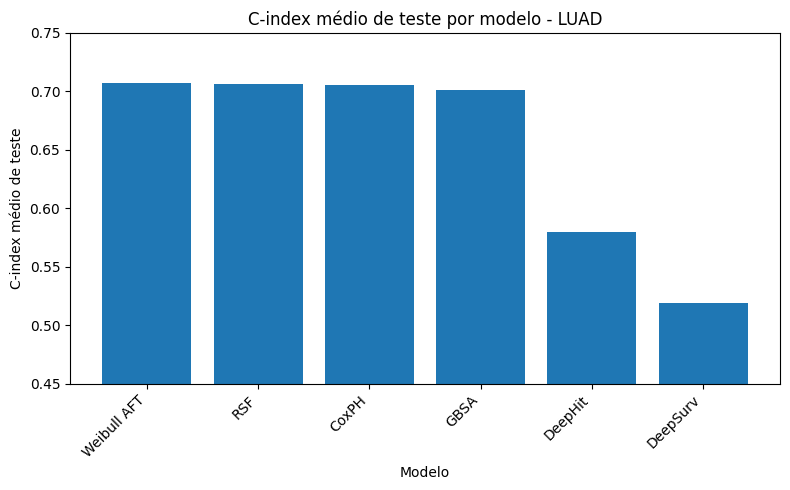

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\figures\luad\luad_cindex_modelos.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    tabela_tcc["modelo"],
    tabela_tcc["c_index_teste_medio"]
)

ax.set_title(f"C-index médio de teste por modelo - {cohort}")
ax.set_xlabel("Modelo")
ax.set_ylabel("C-index médio de teste")
ax.set_ylim(0.45, 0.75)

plt.xticks(rotation=45, ha="right")
fig.tight_layout()

fig.savefig(
    figures_dir / f"{cohort_lower}_cindex_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print(figures_dir / f"{cohort_lower}_cindex_modelos.png")

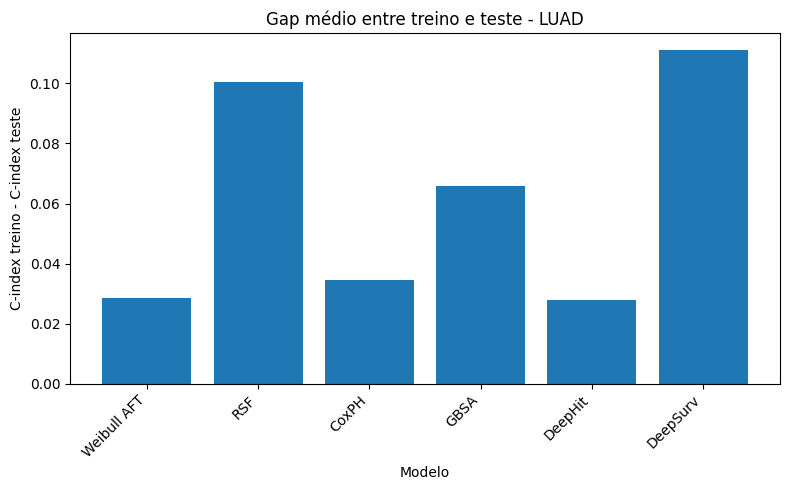

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\figures\luad\luad_gap_modelos.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    tabela_tcc["modelo"],
    tabela_tcc["gap_medio"]
)

ax.set_title(f"Gap médio entre treino e teste - {cohort}")
ax.set_xlabel("Modelo")
ax.set_ylabel("C-index treino - C-index teste")

plt.xticks(rotation=45, ha="right")
fig.tight_layout()

fig.savefig(
    figures_dir / f"{cohort_lower}_gap_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print(figures_dir / f"{cohort_lower}_gap_modelos.png")